<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/Tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 05 - Estatística - Ciências dos Alimentos

Nome: Iago Aparecido Dias dos Santos N​​° USP:16873011

Nome: João Pedro Paschoalini N​​° USP:17831089

Nome: Maria Eduarda Porta N° USP: 17074105

## Análise da Base de Dados USDA

Vamos começar carregando os dados e explorando sua estrutura para responder às perguntas solicitadas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar a base de dados
file_path = '/content/usda_data.xlsx'
df_usda = pd.read_excel(file_path)

# Exibir as primeiras linhas do DataFrame e informações gerais
print("Primeiras 5 linhas do DataFrame:")
display(df_usda.head())

print("\nInformações gerais do DataFrame (tipos de variáveis e valores não nulos):")
df_usda.info()

Primeiras 5 linhas do DataFrame:


,ID,Alimento,Categoria,Proteína (g),Gordura total (g),Sódio (mg),fdc_id
0,1,"Rúcula, baby, crua",Vegetais e Produtos Vegetais,1.648750,0.3250,86.93,2710822
1,2,"Aspargos verdes, crus",Vegetais e Produtos Vegetais,1.437500,0.2163,2.46,2710823
2,3,"Vagem, enlatada, embalagem comum, escorrida",Vegetais e Produtos Vegetais,1.040000,0.3900,282.00,321611
3,4,"Vagem, crua",Vegetais e Produtos Vegetais,1.968750,0.2750,0.00,2346400
4,5,"Folhas de beterraba, cruas",Vegetais e Produtos Vegetais,1.609375,0.1438,280.50,2747653



Informações gerais do DataFrame (tipos de variáveis e valores não nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 100 non-null    int64  
 1   Alimento           100 non-null    object 
 2   Categoria          100 non-null    object 
 3   Proteína (g)       100 non-null    float64
 4   Gordura total (g)  100 non-null    float64
 5   Sódio (mg)         100 non-null    float64
 6   fdc_id             100 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 5.6+ KB


### Pergunta 6: Existem alimentos cujo teor de sódio se distancia consideravelmente dos demais? Como você identificaria e representaria essas observações?

Para identificar e representar alimentos com teor de sódio que se distancia consideravelmente dos demais (outliers), utilizaremos um `boxplot`. O boxplot é uma ferramenta visual eficaz para identificar a distribuição de uma variável e detectar valores atípicos. Outliers são geralmente definidos como pontos que estão além de 1.5 vezes o Intervalo Interquartil (IQR) do primeiro ou terceiro quartil.

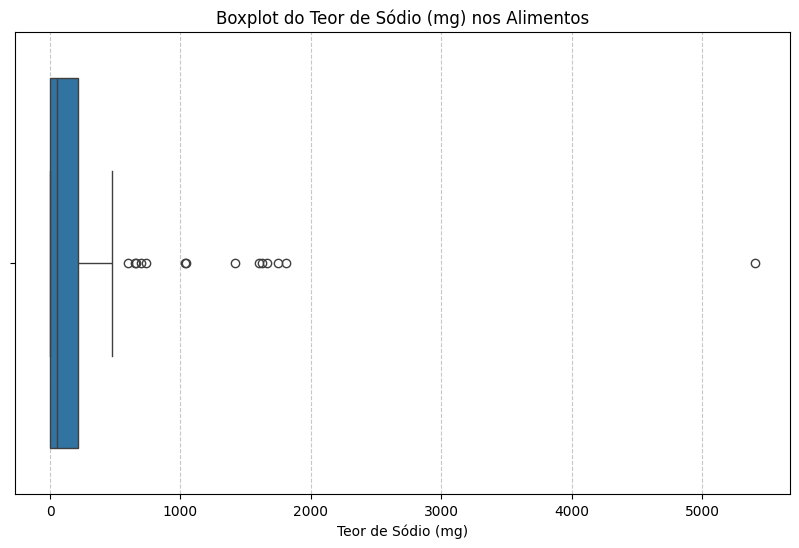


Valores do IQR para Sódio (mg): Q1=2.93, Q3=214.22, IQR=211.29
Limites para identificação de outliers: Inferior=-314.00, Superior=531.16

Alimentos cujo teor de sódio se distancia consideravelmente dos demais (outliers) em miligramas:


,Alimento,Sódio (mg),Justificativa
46,"Queijo americano, tipo restaurante",1600.0,Acima do Limite Superior
47,Queijo cheddar,654.0,Acima do Limite Superior
48,"Queijo cotija, sólido",1625.0,Acima do Limite Superior
50,"Queijo branco seco, queso seco",1810.0,Acima do Limite Superior
51,"Queijo feta, leite integral, esfarelado",1034.0,Acima do Limite Superior
52,"Queijo Monterey Jack, sólido",662.2,Acima do Limite Superior
53,"Queijo muçarela, baixa umidade, parcialmente d...",699.0,Acima do Limite Superior
54,"Queijo Oaxaca, sólido",734.2,Acima do Limite Superior
55,"Queijo parmesão, ralado",1750.0,Acima do Limite Superior
56,"Queijo parmesão, ralado, refrigerado",1046.0,Acima do Limite Superior


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_usda['Sódio (mg)'])
plt.title('Boxplot do Teor de Sódio (mg) nos Alimentos')
plt.xlabel('Teor de Sódio (mg)')
plt.ylabel('') # Removendo o rótulo do eixo Y, pois não é necessário para um boxplot horizontal de uma única variável
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Identificar os outliers estatisticamente usando o método IQR para Sódio (mg)
Q1_mg = df_usda['Sódio (mg)'].quantile(0.25)
Q3_mg = df_usda['Sódio (mg)'].quantile(0.75)
IQR_mg = Q3_mg - Q1_mg

lower_bound_mg = Q1_mg - 1.5 * IQR_mg
upper_bound_mg = Q3_mg + 1.5 * IQR_mg

outliers_sodium_mg = df_usda[(df_usda['Sódio (mg)'] < lower_bound_mg) | (df_usda['Sódio (mg)'] > upper_bound_mg)]

# Adicionar a coluna 'Justificativa' para os outliers
if not outliers_sodium_mg.empty:
    outliers_sodium_mg = outliers_sodium_mg.copy()
    outliers_sodium_mg['Justificativa'] = outliers_sodium_mg['Sódio (mg)'].apply(
        lambda x: 'Acima do Limite Superior' if x > upper_bound_mg else 'Abaixo do Limite Inferior'
    )

print(f"\nValores do IQR para Sódio (mg): Q1={Q1_mg:.2f}, Q3={Q3_mg:.2f}, IQR={IQR_mg:.2f}")
print(f"Limites para identificação de outliers: Inferior={lower_bound_mg:.2f}, Superior={upper_bound_mg:.2f}")

if not outliers_sodium_mg.empty:
    print("\nAlimentos cujo teor de sódio se distancia consideravelmente dos demais (outliers) em miligramas:")
    display(outliers_sodium_mg[['Alimento', 'Sódio (mg)', 'Justificativa']])
else:
    print("\nNão foram encontrados outliers significativos no teor de sódio (mg), com base no critério do IQR.")

### Interpretação Detalhada do Boxplot de Sódio e Outliers (Pergunta 6)

Ao observar o boxplot horizontal do teor de sódio, notamos imediatamente uma distribuição bastante assimétrica. A grande maioria dos alimentos se concentra na faixa de baixo teor de sódio, o que faz com que o gráfico pareça 'achatado' na sua porção inicial, enquanto alguns poucos alimentos se destacam por terem quantidades significativamente mais altas, como verdadeiros **outliers**.

Vamos destrinchar cada parte para entender melhor:

*   **Box**: Esta parte central do boxplot é super importante, pois nos mostra o coração da distribuição dos dados – os 50% centrais dos alimentos. A caixa vai de **2.93 mg (Primeiro Quartil - Q1)** a **214.22 mg (Terceiro Quartil - Q3)**. O fato de ela ser tão estreita e estar no início do gráfico nos diz que metade dos alimentos que analisamos têm um teor de sódio relativamente baixo. Isso indica uma **variabilidade menor** para a maioria dos produtos.

*   **Linha Central (Mediana)**: A linha que atravessa a caixa é a mediana (Q2). Ela representa o valor que divide a base de dados exatamente ao meio: 50% dos alimentos têm sódio abaixo desse ponto e 50% acima. Neste caso, ela está bem próxima ao Q1, reforçando a ideia de que a maior parte dos dados está concentrada nos valores mais baixos.

*   **Whiskers**: Os "Whiskers" se estendem da caixa para indicar a dispersão dos dados que ainda não são considerados outliers. Eles mostram o alcance dos valores "normais". O "bigode" da direita, que se estende para valores mais altos, já começa a nos dar um indício da **maior variabilidade** presente nos alimentos com mais sódio, mesmo antes dos outliers.

*   **Outliers**: Ah, os outliers! Esses pontos isolados que vemos bem distantes à direita dos "Whiskers" são os alimentos que realmente fogem à regra. Eles têm um teor de sódio tão alto que excedem o limite superior de **531.16 mg**, calculado com base em 1.5 vezes o Intervalo Interquartil (IQR). A tabela de outliers, que vimos anteriormente, nos revela que muitos desses são queijos, por exemplo, e eles mostram a **extrema variabilidade** de sódio na base de dados.

**O que esses outliers nos dizem?**

Esses outliers não são apenas pontos no gráfico; eles representam alimentos que têm uma quantidade de sódio consideravelmente mais elevada do que a maioria. Pensando em termos práticos, para quem precisa controlar a ingestão de sódio, esses são os itens que merecem atenção redobrada. Eles nos mostram que, embora muitos alimentos tenham baixo sódio, alguns produtos específicos podem ser grandes contribuintes para a ingestão diária total.

É importante lembrar que, como o teor de sódio é sempre positivo, não é possível ter outliers negativos. O boxplot, ao não exibir pontos abaixo do limite inferior, reflete essa realidade, focando a nossa atenção nos valores excessivamente altos.

In [34]:
mean_sodium = df_usda['Sódio (mg)'].mean()
median_sodium = df_usda['Sódio (mg)'].median()

print(f"Média do teor de Sódio (mg): {mean_sodium:.2f}")
print(f"Mediana do teor de Sódio (mg): {median_sodium:.2f}")

Média do teor de Sódio (mg): 273.09
Mediana do teor de Sódio (mg): 54.47


### Comparação entre Média e Mediana para o Teor de Sódio

A comparação entre a média e a mediana é crucial para entender a forma da distribuição do teor de sódio, especialmente quando observamos assimetria no boxplot.

*   **Média do teor de Sódio**: A média é **273.09 mg**.
*   **Mediana do teor de Sódio**: A mediana é **54.47 mg**.

Como a **média (273.09  mg)** é visivelmente maior que a **mediana (54.47 mg)**, isso é uma forte indicação de que a distribuição do teor de sódio é **assimétrica positiva (ou assimétrica à direita)**. Isso significa que existem alguns valores altos (os outliers que identificamos) que "puxam" a média para cima, enquanto a maioria dos dados se concentra nos valores mais baixos, perto da mediana. Essa diferença numérica confirma o que já observávamos visualmente no boxplot: uma concentração de dados em valores baixos e uma cauda longa para a direita, estendida pelos outliers.

### Pergunta 14: Caso exista uma associação entre essas duas variáveis [Proteína e Gordura], como você descreveria sua intensidade e direção a partir dos dados?

Para investigar a associação entre o teor de proteína e o teor de gordura dos alimentos, utilizaremos um gráfico de dispersão (scatter plot) e calcularemos o coeficiente de correlação de Pearson. O scatter plot nos dará uma visualização da direção e intensidade aparente da relação, enquanto o coeficiente de correlação quantificará essa relação.

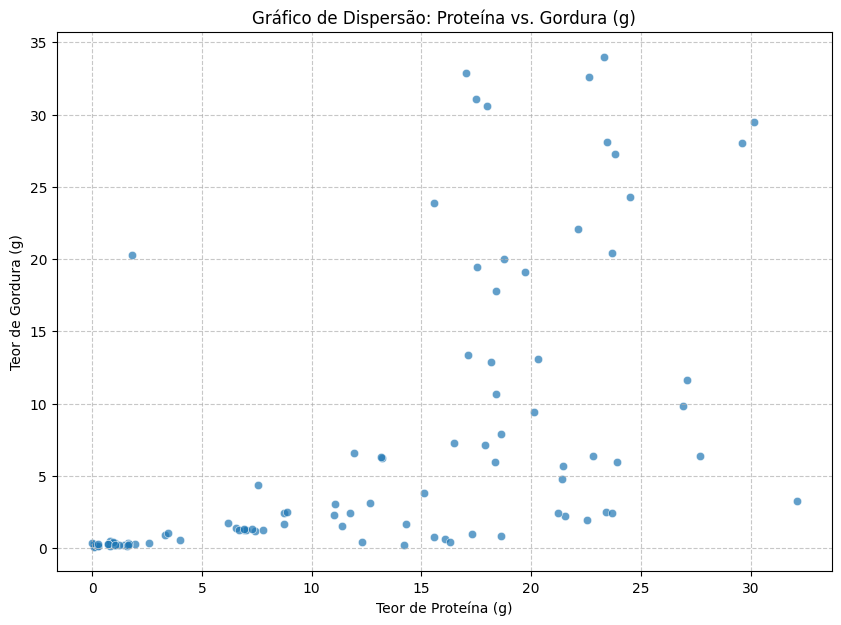


Coeficiente de Correlação de Pearson entre Proteína e Gordura: 0.59

Descrição da intensidade e direção da associação:
Existe uma **correlação positiva moderada** entre Proteína e Gordura.
Há uma tendência de que, ao aumentar o teor de proteína, o teor de gordura também aumente.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Proteína (g)', y='Gordura total (g)', data=df_usda, alpha=0.7)
plt.title('Gráfico de Dispersão: Proteína vs. Gordura (g)')
plt.xlabel('Teor de Proteína (g)')
plt.ylabel('Teor de Gordura (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calcular o coeficiente de correlação de Pearson
correlation = df_usda['Proteína (g)'].corr(df_usda['Gordura total (g)'])

print(f"\nCoeficiente de Correlação de Pearson entre Proteína e Gordura: {correlation:.2f}")

if correlation > 0.7:
    description = "Existe uma **forte correlação positiva** entre Proteína e Gordura.\nÀ medida que o teor de proteína aumenta, o teor de gordura também tende a aumentar significativamente."
elif correlation > 0.3:
    description = "Existe uma **correlação positiva moderada** entre Proteína e Gordura.\nHá uma tendência de que, ao aumentar o teor de proteína, o teor de gordura também aumente."
elif correlation > 0:
    description = "Existe uma **fraca correlação positiva** entre Proteína e Gordura.\nHá uma leve tendência de aumento conjunto, mas não é muito pronunciada."
elif correlation < -0.7:
    description = "Existe uma **forte correlação negativa** entre Proteína e Gordura.\nÀ medida que o teor de proteína aumenta, o teor de gordura tende a diminuir significativamente."
elif correlation < -0.3:
    description = "Existe uma **correlação negativa moderada** entre Proteína e Gordura.\nHá uma tendência de que, ao aumentar o teor de proteína, o teor de gordura diminua."
elif correlation < 0:
    description = "Existe uma **fraca correlação negativa** entre Proteína e Gordura.\nHá uma leve tendência de diminuição do teor de gordura com o aumento da proteína, mas não é muito pronunciada."
else:
    description = "Não há uma correlação linear significativa entre Proteína e Gordura."

print(f"\nDescrição da intensidade e direção da associação:\n{description}")

### Interpretação do Gráfico de Dispersão e Correlação (Pergunta 14)

O gráfico de dispersão sugere uma relação positiva: alimentos com mais proteína tendem a ter mais gordura. O Coeficiente de Correlação de Pearson, de **0.59**, confirma uma **correlação de crescimento** entre proteína e gordura.

Isso significa que, em geral, esses nutrientes aumentam juntos, mas a relação não é perfeita como se **fosse 1** gerando relação sem interferências.